In [10]:
import time
import statistics
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
C1 = [
    ("P01", "Health Check Service",        1,  6),
    ("P02", "Cache Refresh",               2, 11),
    ("P03", "Log Processing",              3, 16),
    ("P04", "Thumbnail Generation",        4, 21),
    ("P05", "Search Index Update",         5, 26),
    ("P06", "Analytics Batch",             6, 31),
    ("P07", "Recommendation Refresh",      7, 36),
    ("P08", "Video Processing",            8, 40),
    ("P09", "Database Maintenance",        9, 45),
    ("P10", "Machine Learning Inference", 10, 50)
     ]

C2 = [
    ("Q10", "Realtime Analytics",       10,  60),
    ("Q20", "Search Reindexing",        20, 100),
    ("Q30", "Video Transcoding",        30, 120),
    ("Q35", "Database Replication",     35, 130),
    ("Q40", "Model Inference Batch",    40, 135),
    ("Q45", "Large ETL Pipeline",       45, 140),
    ("Q50", "Database Migration",       50, 150)
     ]
capacities = {20,35,50,65,80,95,110,140}



In [12]:
def greedy(jobs, w):
    total_cost = 0
    total_relief = 0
    chosen_ids = []

    for job in jobs:
        job_id = job[0]
        job_cost = job[2]
        job_relief = job[3]

        if total_cost + job_cost > w:
            continue
        else:
            total_cost += job_cost
            total_relief += job_relief
            chosen_ids.append(job_id)

    return total_relief, chosen_ids

In [13]:
def dynamic_solver(jobs, capacity_W):
  n = len(jobs)

  # Guarda el mejor valor para cada capacidad
  dp = [0] * (capacity_W + 1)

  # Guarda las decisiones para reconstruir
  # los jobs seleccionados
  take = []

  for i in range(n):
      row = [False] * (capacity_W + 1)
      take.append(row)

  # Revisamos cada job
  for i in range(n):

      weight = jobs[i][2]
      value = jobs[i][3]

      # Recorremos la capacidad de mayor a menor
      # para no usar el mismo job más de una vez
      for c in range(capacity_W, weight - 1, -1):

          new_value = dp[c - weight] + value

          if new_value > dp[c]:

              dp[c] = new_value
              take[i][c] = True

  # Reconstrucción de los jobs seleccionados
  chosen_ids = []

  c = capacity_W

  for i in range(n - 1, -1, -1):

      if take[i][c]:

          job_id = jobs[i][0]
          weight = jobs[i][2]

          chosen_ids.append(job_id)

          c = c - weight

  chosen_ids.reverse()

  return dp[capacity_W], chosen_ids

In [14]:
from typing import List, Tuple, Any

def branch_and_bound(jobs: List[Tuple[Any, str, int, int]], capacity_W: int) -> Tuple[int, List[Any]]:

  # si la 'integer offloading capacity' es cero o menor, o ya no hay trabajos, devolvemos cero y la lista vacia
  if capacity_W <= 0 or len(jobs) == 0:
    return 0, []

  # hacemos una copia de los trabajos
  order = jobs[:]

  # ordenamos los trabajos de mayor a menor relacion valor/costo
  for i in range(len(order)):
    for j in range(i + 1, len(order)):

      vwi = order[i][3] / order[i][2] # calculamos la relacion valor/costo: vi / wi
      vwj = order[j][3] / order[j][2]

      if vwi < vwj:
        temp = order[i]
        order[i] = order[j]
        order[j] = temp

  n = len(order)

  # guardamos el mejor valor y los identificadores de los trabajos elegidos
  mejorValue = 0
  mejorSet = []

  # función para calcular el 'upper bound'
  def ubound(i, remaining, value):
    upper = value
    capacityLeft = remaining

    while i < n and order[i][2] <= capacityLeft: # restamos el costo a la capacidad restante y agregamos el valor del trabajo
      capacityLeft -= order[i][2]
      upper += order[i][3]
      i += 1

    if i < n and capacityLeft > 0: # si quedara capacidad y trabajos pero no para un trabajo completo tomamos una parte de el
      rm = capacityLeft / order[i][2] # se calcula parte del trabajo que se puede tomar en cuenta
      upper += rm * order[i][3]

    return upper

  def dfs(i, remaining, value, chosen):
    nonlocal mejorValue, mejorSet

    if value > mejorValue: # revisar si lo actual es mejor que la solución anterior
      mejorValue = value
      mejorSet = chosen[:]

    if i == n or remaining == 0: # si ya no quedan trabajos ni capacidad
      return

    UB = ubound(i, remaining, value)

    if UB <= mejorValue:
      return

    weight = order[i][2] # obtenemos costo y valor del trabajo
    jobV = order[i][3]

    if weight <= remaining: # si el trabajo cabe en la capacidad disponible agregamos el ID del trabajo a la lista de elegidos
      chosen.append(order[i][0])
      dfs(i + 1, remaining - weight, value + jobV, chosen) # exploramos la rama y seguimos con el siguiente trabajo

      chosen.pop() # lo quitamos para explorar otra rama

    dfs(i + 1, remaining, value, chosen) # no seleccionar el trabajo

  # explorar desde el primer trabajo sin seleccionar nada
  dfs(0, capacity_W, 0, [])

  # ordenamos los ID
  mejorSet.sort()

  return mejorValue, mejorSet

In [15]:
methods = {
    "Greedy": greedy,
    "Dynamic": dynamic_solver,
    "Branch and Bound": branch_and_bound
}

In [16]:
def validate_solution(jobs, capacity_W, reported_relief, chosen_ids):

    jobs_by_id = {job[0]: job for job in jobs}


    for job_id in chosen_ids:
        if job_id not in jobs_by_id:
            return False, f"El job {job_id} no existe"

    if len(chosen_ids) != len(set(chosen_ids)):
        return False, "Hay jobs repetidos"


    total_cost = 0
    total_relief = 0

    for job_id in chosen_ids:
        job = jobs_by_id[job_id]
        total_cost += job[2]
        total_relief += job[3]


    if total_cost > capacity_W:
        return False, "El costo total supera la capacidad W"

    if total_relief != reported_relief:
        return False, "El load relief no coincide con los jobs seleccionados"

    return True, "Solución válida", total_cost


In [17]:
def runMethods():
    workloads = {"C1": C1, "C2": C2}
    sorted_capacities = sorted(capacities)
    results = []

    for workloadName, jobs in workloads.items():
        for W in capacities:
            solver_outputs = {}

            # Para cada Worklad, por cada capacidad, por cada método se mide el runtime
            for methodName, method in methods.items():
                runtimes = []

                for _ in range(5):
                    startTime = time.perf_counter()
                    val, selectedIds = method(jobs, W)
                    endTime = time.perf_counter()
                    runtime_ms = (endTime - startTime) * 1000
                    runtimes.append(runtime_ms)
                # se calcula la mediana de los 5 runtimes
                medianRuntime = statistics.median(runtimes)

                #Se valida el id seleccionado y su valor (output)
                is_valid, message, totalMigrationCost = validate_solution(
                    jobs,W,val,selectedIds
                )

                if not is_valid:
                    raise ValueError(
                        f"Invalid solution returned by {methodName} "
                    )

                solver_outputs[methodName] = {
                    "best value": val,
                    "chosen ids": selectedIds,
                    "runtimes": runtimes,
                    "median runtime": medianRuntime,
                    "total cost": totalMigrationCost
                }

            #load relief
            greedyValue = solver_outputs["Greedy"]["best value"]
            dpValue = solver_outputs["Dynamic"]["best value"]
            bbValue = solver_outputs["Branch and Bound"]["best value"]

            # VErificar DP and B&B regresan el mismo valor optimo
            if dpValue != bbValue:
                raise ValueError(f"Mismatch in exact solvers for {workloadName}, W={W}: DP={dpValue}, B&B={bbValue}")

            # Verificar Greedy nunca excede lo optimo
            if greedyValue > dpValue:
                raise ValueError(f"Greedy value ({greedyValue}) exceeded optimal value ({dpValue}) for {workloadName}, W={W}")

            greedyOptimalityGap = dpValue - greedyValue

            #se guardan los resultados
            for methodName in methods:
                output = solver_outputs[methodName]
                results.append({
                    "workload": workloadName,
                    "capacity": W,
                    "method": methodName,
                    "runtimes": output["runtimes"],
                    "median runtime": output["median runtime"],
                    "best value": output["best value"],
                    "chosen ids": output["chosen ids"],
                    "total cost": output["total cost"],
                    "optimality gap": greedyOptimalityGap
                })

    return results

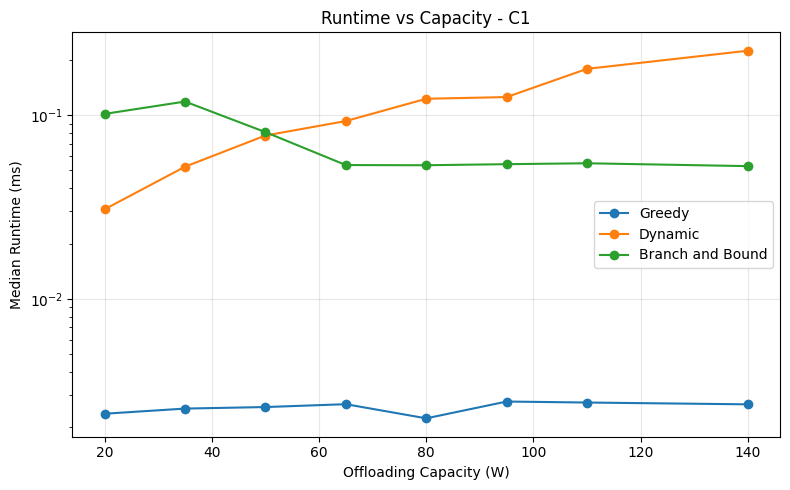

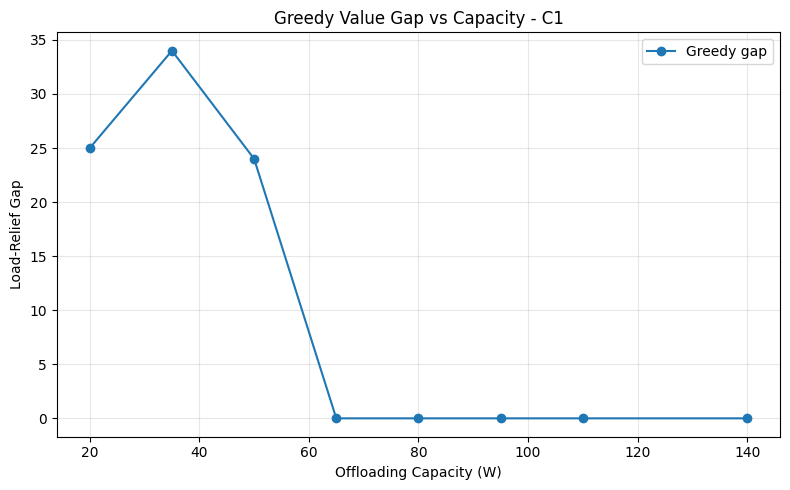

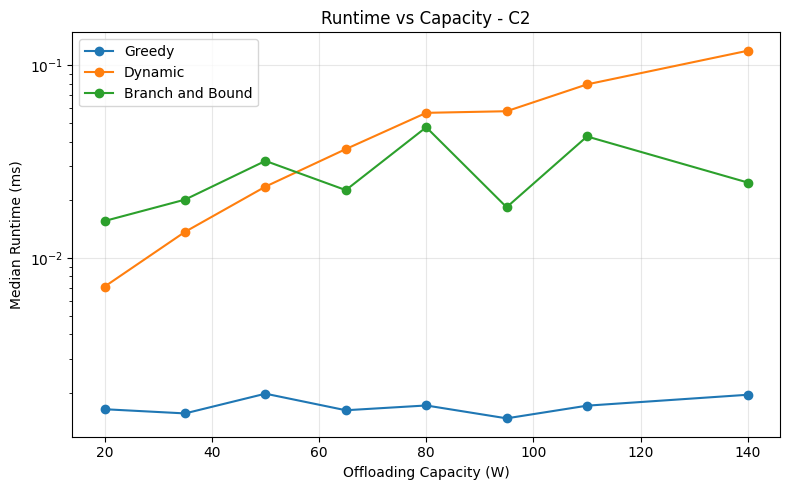

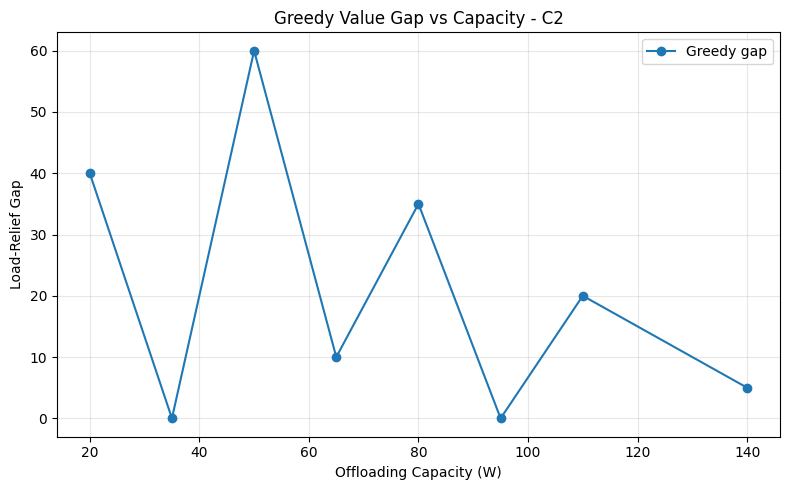

   workload  capacity            method  median runtime  best value  \
0        C1        65            Greedy        0.002670         282   
1        C1        65           Dynamic        0.092812         282   
2        C1        65  Branch and Bound        0.053467         282   
3        C1        35            Greedy        0.002527         147   
4        C1        35           Dynamic        0.052364         181   
5        C1        35  Branch and Bound        0.118499         181   
6        C1       140            Greedy        0.002665         282   
7        C1       140           Dynamic        0.224105         282   
8        C1       140  Branch and Bound        0.052753         282   
9        C1       110            Greedy        0.002726         282   
10       C1       110           Dynamic        0.178540         282   
11       C1       110  Branch and Bound        0.054681         282   
12       C1        80            Greedy        0.002236         282   
13    

In [18]:
def createGraphs(results):
    workloads = ["C1", "C2"]

    results = sorted(results, key=lambda x: x["capacity"])

    for workload in workloads:
        #Runtime vs Capacity
        plt.figure(figsize=(8, 5))

        for method in methods:
            capacities_for_method = []
            median_runtimes = []

            for result in results:
                if (result["workload"] == workload and result["method"] == method):
                    capacities_for_method.append(result["capacity"])
                    median_runtimes.append(result["median runtime"])

            plt.plot(
                capacities_for_method,
                median_runtimes,
                marker="o",
                label=method
            )

        plt.xlabel("Offloading Capacity (W)")
        plt.ylabel("Median Runtime (ms)")
        plt.title(f"Runtime vs Capacity - {workload}")
        plt.legend()
        plt.grid(True, alpha=0.3)

        #Use this if the runtime differences are large
        plt.yscale("log")
        plt.tight_layout()
        plt.savefig(
            f"runtime_vs_capacity_{workload}.png",
            dpi=300
        )
        plt.savefig(
            f"runtime_vs_capacity_{workload}.pdf"
        )
        plt.show()
        plt.close()


        # Greedy Value Gap vs Capacity

        plt.figure(figsize=(8, 5))

        capacities_for_gap = []
        greedy_gaps = []

        for result in results:
            if (result["workload"] == workload and result["method"] == "Greedy"):
                capacities_for_gap.append(result["capacity"])
                greedy_gaps.append(result["optimality gap"])

        plt.plot(
            capacities_for_gap,
            greedy_gaps,
            marker="o",
            label="Greedy gap"
        )

        plt.xlabel("Offloading Capacity (W)")
        plt.ylabel("Load-Relief Gap")
        plt.title(f"Greedy Value Gap vs Capacity - {workload}")
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            f"greedy_gap_vs_capacity_{workload}.png",
            dpi=300
        )

        plt.savefig(
            f"greedy_gap_vs_capacity_{workload}.pdf"
        )
        plt.show()
        plt.close()


results = runMethods()
createGraphs(results)

df = pd.DataFrame(results)
print(df.drop(columns=["runtimes"]))